
-----
#### MS: Unique patterns of mutations in childhood cancer highlight chemotherapy’s disease-defining role at relapse
### Main Figure 6
-----

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from matplotlib.lines import Line2D
import seaborn as sns

from importlib import reload

import os
import sys
import random

A_col = "#3288BD"
B_col = "#D53E4F"

import warnings
warnings.filterwarnings('ignore')

random.seed(42)

-----
##### Set up input / output directories

In [2]:
## Provide an output directory for figures or use 'installation_folder/figures' directory
root_dir = os.path.dirname(os.getcwd())
fig_out = os.path.join(root_dir, 'figures')
## Or provide a results path
#fig_out = '/Users/dir1/dir2/Figures'

-----
##### Load helper scripts

In [3]:
sys.path.append(str(root_dir))
import scripts.ml_utils as mu

-----------
## Panel a

In [4]:
mat96_rel = pd.read_csv(os.path.join(root_dir, 'source_data/Fig_6a.tsv'), sep='\t', index_col=0)

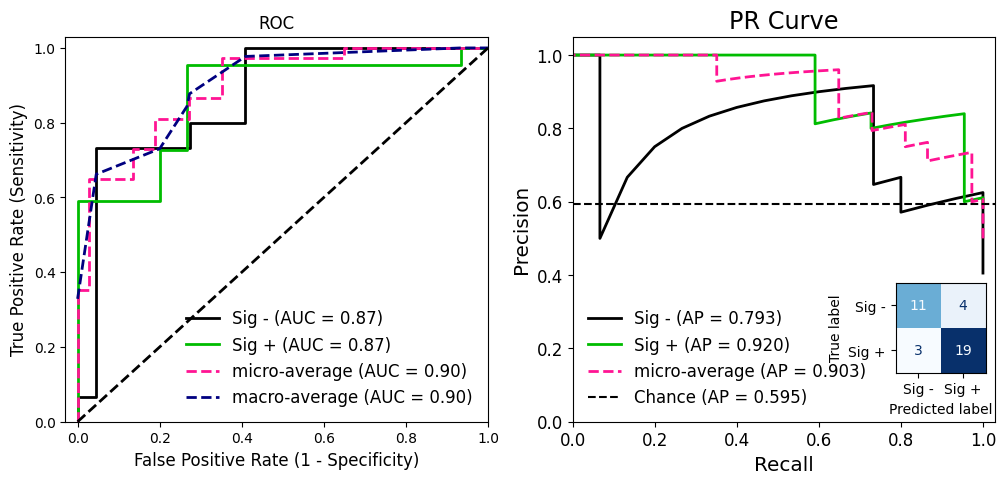

In [5]:
voting_sbs = mu.get_votingClf_v2(mat96_rel, cv=True, extra_plots=True)
#plt.savefig(os.path.join(fig_out, 'Fig_6a.pdf'), bbox_inches="tight")

-----------
## Panel b

In [32]:
vc_scores = pd.read_csv(os.path.join(root_dir, 'source_data/Fig_6b.tsv'), sep='\t')
vc_scores_vals = vc_scores[vc_scores.Status=='vals'].set_index('Category')
vc_scores_yerr = vc_scores[vc_scores.Status=='yerr'].set_index('Category')

In [33]:
mute_cols = sns.color_palette("muted")   #['#86BBD8', '#878E99', '#33658B']

[Text(0, 0.0, '0.0'),
 Text(0, 0.2, '0.2'),
 Text(0, 0.4, '0.4'),
 Text(0, 0.6000000000000001, '0.6'),
 Text(0, 0.8, '0.8'),
 Text(0, 1.0, '1.0'),
 Text(0, 1.2000000000000002, '1.2')]

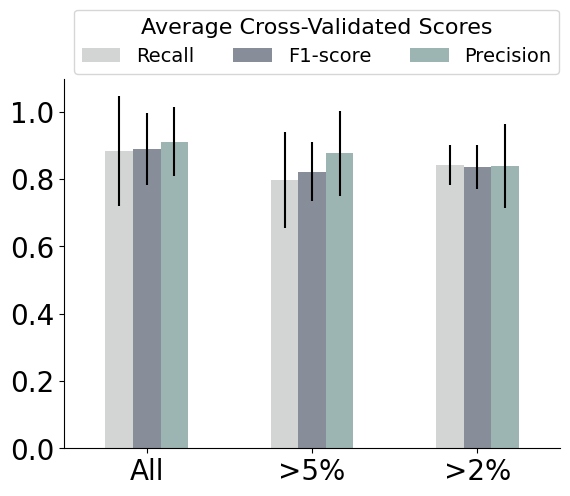

In [34]:
fig2,ax2 = plt.subplots()
vc_scores_vals.plot(kind='bar',yerr=vc_scores_yerr, color=['#D3D5D4', '#878E99', '#9DB5B2'], ax=ax2)
leg =ax2.legend(loc='center left', bbox_to_anchor=(0, 1.1), ncols=3, title='Average Cross-Validated Scores', fontsize=14)
leg.get_title().set_fontsize('16')
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_xlabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontsize=20)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=20)

#plt.savefig(os.path.join(fig_out, 'Fig_5b.pdf'), bbox_inches="tight")

-----------
## Panels c-d

In [6]:
reports96_1h = pd.read_csv(os.path.join(root_dir, 'source_data/Fig_6c.tsv'), sep='\t')
reports96_1h.head(2)

,Signature,Precision,Recall,F1-score,Support,Positive Class (in Red)
0,Sig -,0.784615,0.894737,0.836066,57.0,Platinum\nTreated
1,Sig +,0.877551,0.754386,0.811321,57.0,Platinum\nTreated


In [7]:
model_ind, features_S = mu.shap_swarm_single_v2(mat96_rel)
features_df_S = mu.SBS_feats_2df(features_S, 'Sig-/+')

In [8]:
colors = {'C>A': [3 / 256, 189 / 256, 239 / 256],
          'C>G': [1 / 256, 1 / 256, 1 / 256],
          'C>T': [228 / 256, 41 / 256, 38 / 256],
          'T>A': [203 / 256, 202 / 256, 202 / 256],
          'T>C': [162 / 256, 207 / 256, 99 / 256],
          'T>G': [236 / 256, 199 / 256, 197 / 256],
}

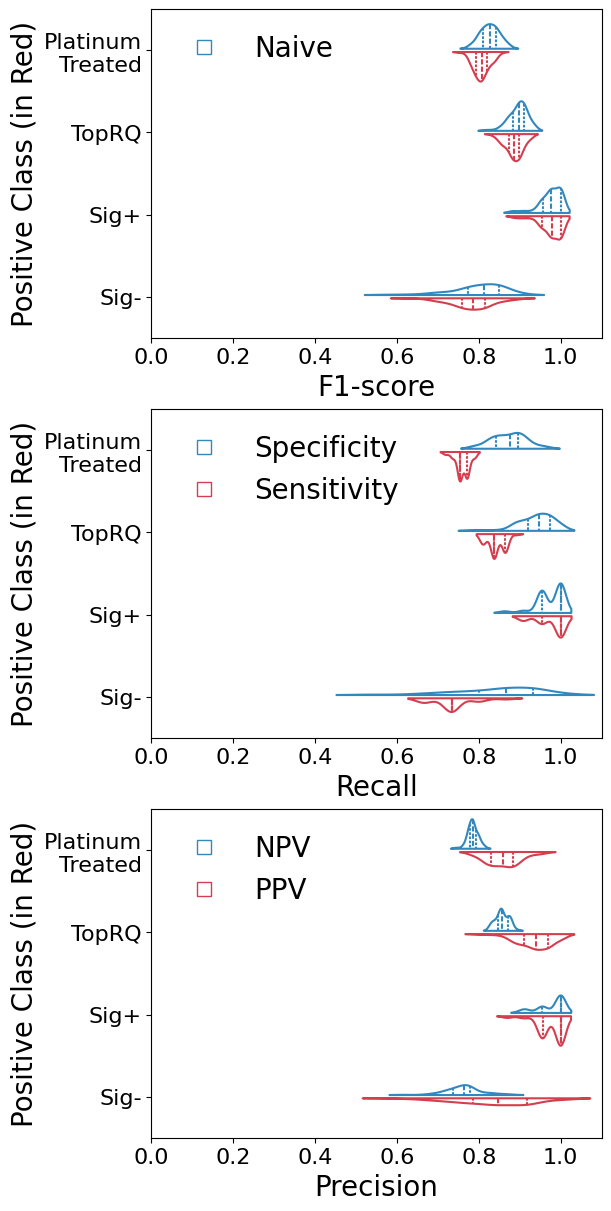

In [12]:
# ── Independent figure: 3 violin subplots stacked vertically ──────────────────
fig_violins, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 12),
                                             constrained_layout=True,
                                             sharex=False)

# ── Subplot 1: F1-score ───────────────────────────────────────────────────────
sns.violinplot(data=reports96_1h, y="Positive Class (in Red)", x="F1-score", hue="Signature",
               split=True, gap=.1, inner="quart", palette={'Sig -': A_col, 'Sig +': B_col},
               fill=False, ax=ax1)
custom_lines = [Line2D([], [], color=A_col, marker='s', markerfacecolor='none',
                        markersize=10, linestyle='none', lw=4)]
ax1.legend(custom_lines, ['Naive'], loc='upper left', fontsize=20, frameon=False)
ax1.set_xlim(0, 1.1)
ax1.xaxis.get_label().set_fontsize(20)
ax1.yaxis.get_label().set_fontsize(20)
ax1.tick_params(axis='both', which='major', labelsize=16)

# ── Subplot 2: Recall ─────────────────────────────────────────────────────────
sns.violinplot(data=reports96_1h, y="Positive Class (in Red)", x="Recall", hue="Signature",
               split=True, gap=.1, inner="quart", palette={'Sig -': A_col, 'Sig +': B_col},
               fill=False, ax=ax2)
custom_lines2 = [Line2D([], [], color=A_col, marker='s', markerfacecolor='none',
                         markersize=10, linestyle='none', lw=4),
                 Line2D([], [], color=B_col, marker='s', markerfacecolor='none',
                         markersize=10, linestyle='none', lw=4)]
ax2.legend(custom_lines2, ['Specificity', 'Sensitivity'], loc='upper left', fontsize=20, frameon=False)
ax2.set_xlim(0, 1.1)
ax2.xaxis.get_label().set_fontsize(20)
ax2.yaxis.get_label().set_fontsize(20)
ax2.tick_params(axis='both', which='major', labelsize=16)

# ── Subplot 3: Precision ──────────────────────────────────────────────────────
sns.violinplot(data=reports96_1h, y="Positive Class (in Red)", x="Precision", hue="Signature",
               split=True, gap=.1, inner="quart", palette={'Sig -': A_col, 'Sig +': B_col},
               fill=False, ax=ax3)
custom_lines3 = [Line2D([], [], color=A_col, marker='s', markerfacecolor='none',
                         markersize=10, linestyle='none', lw=4),
                 Line2D([], [], color=B_col, marker='s', markerfacecolor='none',
                         markersize=10, linestyle='none', lw=4)]
ax3.legend(custom_lines3, ['NPV', 'PPV'], loc='upper left', fontsize=20, frameon=False)
ax3.set_xlim(0, 1.1)
ax3.xaxis.get_label().set_fontsize(20)
ax3.yaxis.get_label().set_fontsize(20)
ax3.tick_params(axis='both', which='major', labelsize=16)

plt.savefig(os.path.join(fig_out, 'Fig_violins.pdf'), bbox_inches="tight", dpi=300)
plt.show()

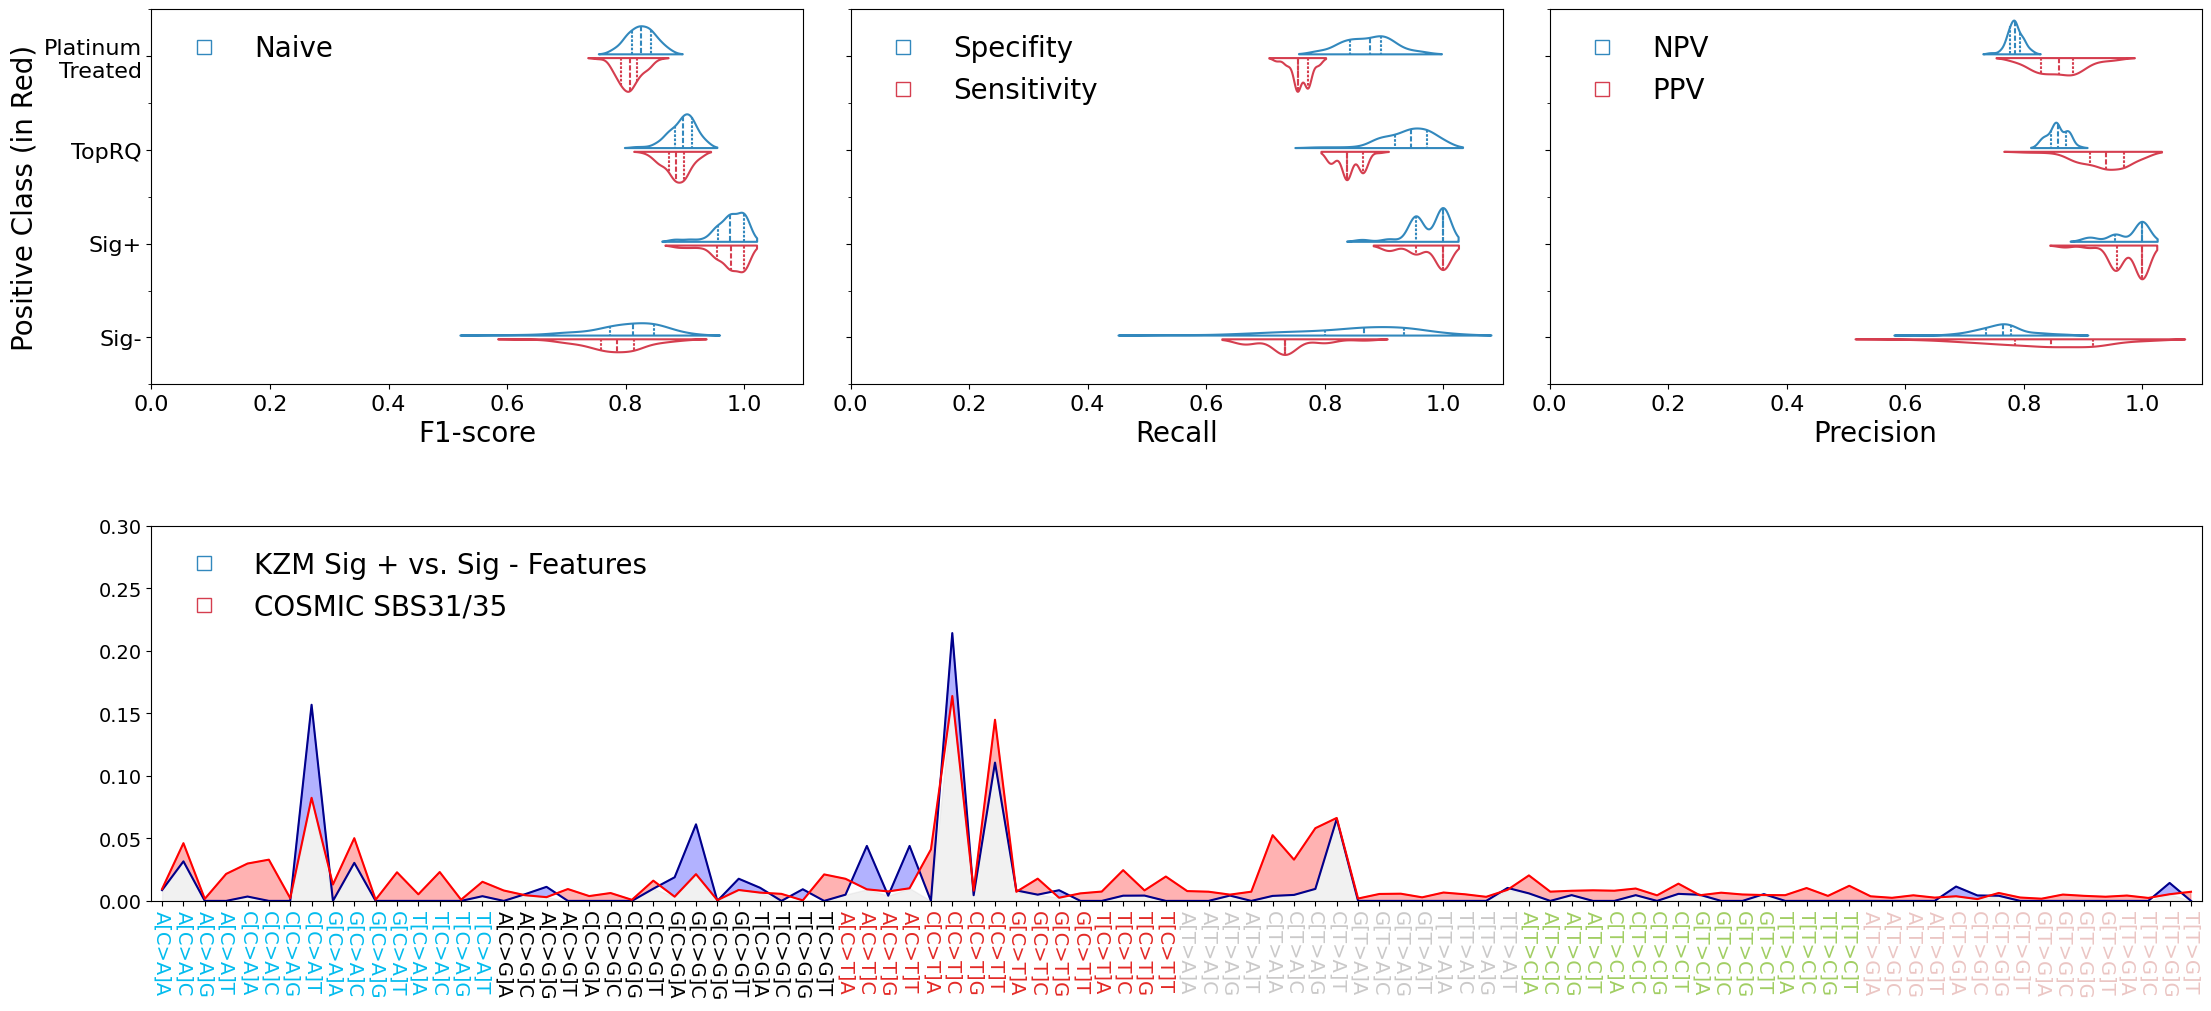

In [51]:
fig3 = plt.figure(figsize=(22,10), constrained_layout=True)
gs = fig3.add_gridspec(13, 3)
f3_ax1 = fig3.add_subplot(gs[0:6, 0])

vp = sns.violinplot(data=reports96_1h, y="Positive Class (in Red)", x="F1-score", hue="Signature",
                    split=True, gap=.1, inner="quart", palette={'Sig -': A_col, 'Sig +': B_col},
                    fill=False, ax=f3_ax1)
custom_lines = [Line2D([], [], color=A_col, marker='s', markerfacecolor='none', markersize=10, linestyle='none', lw=4)]
f3_ax1.legend(custom_lines, ['Naive'], loc='upper left', fontsize=20, frameon=False)
f3_ax1.set_xlim(0, 1.1)
f3_ax1.xaxis.get_label().set_fontsize(20)
f3_ax1.yaxis.get_label().set_fontsize(20)
f3_ax1.tick_params(axis='both', which='major', labelsize=16)


f3_ax2 = fig3.add_subplot(gs[0:6, -2], sharey=f3_ax1)
plt.setp(f3_ax2.get_yticklabels(), visible=False)

vp = sns.violinplot(data=reports96_1h, y="Positive Class (in Red)", x="Recall", hue="Signature",
                    split=True, gap=.1, inner="quart", palette={'Sig -': A_col, 'Sig +': B_col},
                    fill=False, ax=f3_ax2)

custom_lines2 = [Line2D([], [], color=A_col, marker='s', markerfacecolor='none', markersize=10, linestyle='none', lw=4),
                 Line2D([], [], color=B_col, marker='s', markerfacecolor='none', markersize=10, linestyle='none', lw=4)]
f3_ax2.legend(custom_lines2, ['Specifity', 'Sensitivity'], loc='upper left', fontsize=20, frameon=False)
f3_ax2.set_xlim(0, 1.1)
f3_ax2.xaxis.get_label().set_fontsize(20)
f3_ax2.yaxis.get_label().set_fontsize(20)
f3_ax2.tick_params(axis='both', which='major', labelsize=16)


f3_ax3 = fig3.add_subplot(gs[0:6, -1], sharey=f3_ax1)
plt.setp(f3_ax3.get_yticklabels(), visible=False)

vp = sns.violinplot(data=reports96_1h, y="Positive Class (in Red)", x="Precision", hue="Signature",
                    split=True, gap=.1, inner="quart", palette={'Sig -': A_col, 'Sig +': B_col},
                    fill=False, ax=f3_ax3)

custom_lines3 = [Line2D([], [], color=A_col, marker='s', markerfacecolor='none', markersize=10, linestyle='none', lw=4),
                 Line2D([], [], color=B_col, marker='s', markerfacecolor='none', markersize=10, linestyle='none', lw=4)]
f3_ax3.legend(custom_lines3, ['NPV', 'PPV'], loc='upper left', fontsize=20, frameon=False)
f3_ax3.set_xlim(0, 1.1)
f3_ax3.xaxis.get_label().set_fontsize(20)
f3_ax3.yaxis.get_label().set_fontsize(20)
f3_ax3.tick_params(axis='both', which='major', labelsize=16)


f3_ax4 = fig3.add_subplot(gs[7:, :])

feats96_df1_extra = pd.concat([features_df_S, cos_sigs.loc[['SBS31', 'SBS35']].T], axis=1)
feats96_df1_extra['SBS31/35'] = feats96_df1_extra[['SBS31', 'SBS35']].max(axis=1)
feats96_df1_extra[['Sig-/+', 'SBS31/35']].plot(color=['darkblue', 'red'], ax=f3_ax4)
f3_ax4.set_xticks(list(range(0, len(feats96_df1_extra))), feats96_df1_extra.index)
plt.setp(f3_ax4.xaxis.get_majorticklabels(), rotation=-90, ha="center", fontsize=8)
plt.fill_between(feats96_df1_extra.index, feats96_df1_extra[['Sig-/+', 'SBS31/35']].min(axis=1), color='lightgray', alpha=0.3)
plt.fill_between(feats96_df1_extra.index, feats96_df1_extra['Sig-/+'], feats96_df1_extra['SBS31/35'],
                 where=(feats96_df1_extra['Sig-/+'] > feats96_df1_extra['SBS31/35']), color='blue', alpha=0.3, interpolate=True)
plt.fill_between(feats96_df1_extra.index, feats96_df1_extra['Sig-/+'], feats96_df1_extra['SBS31/35'],
                 where=(feats96_df1_extra['Sig-/+'] < feats96_df1_extra['SBS31/35']), color='red', alpha=0.3, interpolate=True)
f3_ax4.set_xlim(-0.5, 95.5)
f3_ax4.set_ylim(0, 0.3)
f3_ax4.tick_params(axis='both', which='major', labelsize=14)

f3_ax4.legend(custom_lines3, ['KZM Sig + vs. Sig - Features', 'COSMIC SBS31/35'], loc='upper left', fontsize=20, frameon=False)

labels = f3_ax4.get_xticklabels()
for label in labels:
    label.set_color(colors[label.get_text()[2:5]])

#plt.savefig(os.path.join(fig_out, 'Fig_5cd.pdf'), bbox_inches="tight", dpi=300)